In [4]:
%load_ext autoreload
%autoreload 2
# import numpy as np
import matplotlib.pyplot as plt
import bayesnewton
import objax
import time
import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)

from model import ExactMarkovGP

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Single spatial coordinate

In [ ]:
# Make some training data
N_temporal_train = 10
N_spatial = 3
t = jnp.linspace(0., 2., N_temporal_train)
r = jnp.linspace(0., 1., N_spatial)
R = jnp.tile(r, (N_temporal_train, 1))
X = jnp.stack([jnp.tile(t[:, None], N_spatial).ravel(), R.ravel()], axis=1)
Y = (5 * X[:, 0] + jnp.sin(2*jnp.pi*X[:, 0]) + 10 * X[:, 1])
Y = Y.reshape(N_temporal_train, N_spatial)
noise_cov = jnp.tile(jnp.eye(N_spatial) * 0.001, (N_temporal_train, 1, 1))
t.shape, R.shape, Y.shape

((10,), (10, 3), (10, 3))

In [ ]:
# Define spatiotemporal kernel and measurement noise likelihood
lengthscale_spatial = 0.1
lengthscale_temporal = 0.5
variance_spatial = 2.0
variance_temporal = 6.0
variance_noise = 0.001 # Set very small to approximate zero noise data (doesn't work if set to zero)

likelihood = bayesnewton.likelihoods.Gaussian(variance=variance_noise)
kern_time = bayesnewton.kernels.Matern32(variance=variance_temporal, lengthscale=lengthscale_temporal)
kern_space = bayesnewton.kernels.Matern32(variance=variance_spatial, lengthscale=lengthscale_spatial)
kernel = bayesnewton.kernels.SpatioTemporalKernel(temporal_kernel=kern_time, spatial_kernel=kern_space, z=R[0], sparse=False, opt_z=False)
H = kernel.measurement_model()
gp = ExactMarkovGP(kernel=kernel, likelihood=likelihood, X=t, Y=Y, R=R)

Text(0.5, 1.0, 'Marginal likelhood: -134.191308873403')

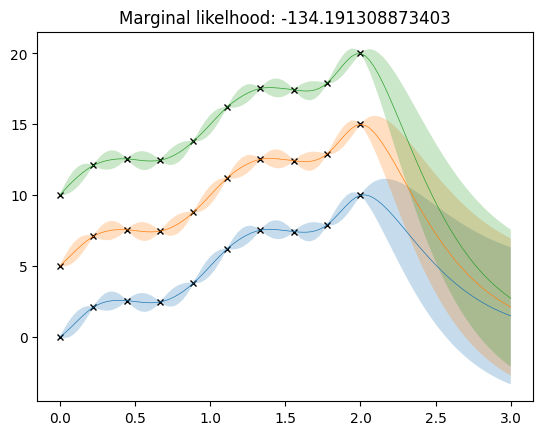

In [ ]:
t_test = jnp.linspace(0., 3., 100)[:, None]
test_mean, test_std = gp.predict(t_test)
plt.plot(t, Y, color='black', marker='x', linestyle='none', ms=5)
plt.plot(t_test, test_mean, lw=.5)
plt.fill_between(t_test.squeeze(), test_mean[:, 0] - 2 * test_std[:, 0], test_mean[:, 0] + 2 * test_std[:, 0], alpha=0.25)
plt.fill_between(t_test.squeeze(), test_mean[:, 1] - 2 * test_std[:, 1], test_mean[:, 1] + 2 * test_std[:, 1], alpha=0.25)
plt.fill_between(t_test.squeeze(), test_mean[:, 2] - 2 * test_std[:, 2], test_mean[:, 2] + 2 * test_std[:, 2], alpha=0.25)
plt.title(f"Marginal likelhood: {-gp.filter_energy()}")

In [ ]:
lr_adam = 0.05
epochs = 100

opt_hypers = objax.optimizer.Adam(gp.vars())
energy = objax.GradValues(gp.filter_energy, gp.vars())

def train_op():
    grads, loss_ = energy()  # compute energy and its gradients w.r.t. hypers
    opt_hypers(lr_adam, grads)
    return loss_[0]

train_op = objax.Jit(train_op, gp.vars())

t0 = time.time()
for i in range(1, epochs+1):
    loss = train_op()
    print('epoch %2d: loss: %1.4f' % (i, loss))
t1 = time.time()
print('optimisation time: %2.2f secs' % (t1-t0))

epoch  1: loss: 54.7133
epoch  2: loss: 54.7043
epoch  3: loss: 54.7045
epoch  4: loss: 54.6955
epoch  5: loss: 54.6958
epoch  6: loss: 54.6869
epoch  7: loss: 54.6872
epoch  8: loss: 54.6783
epoch  9: loss: 54.6786
epoch 10: loss: 54.6698
epoch 11: loss: 54.6702
epoch 12: loss: 54.6614
epoch 13: loss: 54.6619
epoch 14: loss: 54.6531
epoch 15: loss: 54.6536
epoch 16: loss: 54.6449
epoch 17: loss: 54.6454
epoch 18: loss: 54.6367
epoch 19: loss: 54.6373
epoch 20: loss: 54.6287
epoch 21: loss: 54.6293
epoch 22: loss: 54.6207
epoch 23: loss: 54.6213
epoch 24: loss: 54.6128
epoch 25: loss: 54.6135
epoch 26: loss: 54.6050
epoch 27: loss: 54.6057
epoch 28: loss: 54.5972
epoch 29: loss: 54.5980
epoch 30: loss: 54.5895
epoch 31: loss: 54.5904
epoch 32: loss: 54.5820
epoch 33: loss: 54.5828
epoch 34: loss: 54.5744
epoch 35: loss: 54.5753
epoch 36: loss: 54.5670
epoch 37: loss: 54.5679
epoch 38: loss: 54.5596
epoch 39: loss: 54.5606
epoch 40: loss: 54.5523
epoch 41: loss: 54.5534
epoch 42: loss: 

In [630]:
kernel.spatial_kernel.lengthscale, kernel.temporal_kernel.lengthscale, kernel.spatial_kernel.variance, kernel.temporal_kernel.variance

(Array(0.1, dtype=float64, weak_type=True),
 Array(2.69200415, dtype=float64, weak_type=True),
 Array(2., dtype=float64, weak_type=True),
 Array(25.98955848, dtype=float64, weak_type=True))

In [ ]:
t_test = jnp.linspace(0., 3., 100)[:, None]
test_mean, test_std = gp.predict(t_test)

Text(0.5, 1.0, 'Marginal likelhood: -54.36483156582663')

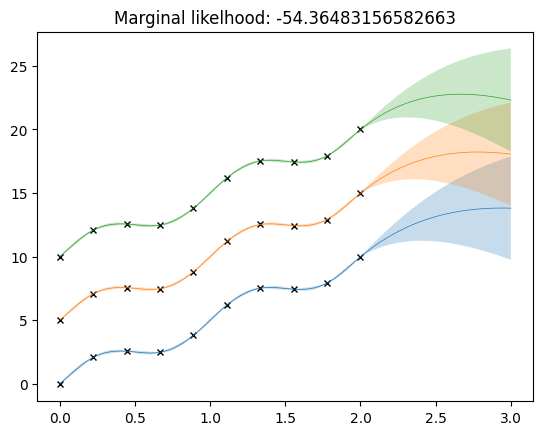

In [ ]:
plt.plot(t, Y, color='black', marker='x', linestyle='none', ms=5)
plt.plot(t_test, test_mean, lw=.5)
plt.fill_between(t_test.squeeze(), test_mean[:, 0] - 2 * test_std[:, 0], test_mean[:, 0] + 2 * test_std[:, 0], alpha=0.25)
plt.fill_between(t_test.squeeze(), test_mean[:, 1] - 2 * test_std[:, 1], test_mean[:, 1] + 2 * test_std[:, 1], alpha=0.25)
plt.fill_between(t_test.squeeze(), test_mean[:, 2] - 2 * test_std[:, 2], test_mean[:, 2] + 2 * test_std[:, 2], alpha=0.25)
plt.title(f"Marginal likelhood: {-gp.filter_energy()}")

# Multiple spatial coordinates

In [5]:
# Make some training data
N_temporal_train = 100
N_x, N_y = 4, 6
N_spatial = N_x * N_y
N_dim = 2
t = jnp.linspace(0., 2., N_temporal_train)
x = jnp.linspace(0., 1., N_x)
y = jnp.linspace(0., 1., N_y)
x, y = jnp.meshgrid(x, y)
r = jnp.stack([x.ravel(), x.ravel()], axis=1)
R = jnp.tile(r, (N_temporal_train, 1, 1))
X = jnp.concatenate([jnp.tile(t[:, None], N_spatial).reshape(-1, 1), R.reshape(-1, N_dim)], axis=1) # Need to compute Y
Y = (5 * X[:, 0] + jnp.sin(2*jnp.pi*X[:, 0]) + 3 * X[:, 1]) + 10 * X[:, 2]
Y = Y.reshape(N_temporal_train, N_spatial)
t.shape, R.shape, Y.shape

((100,), (100, 24, 2), (100, 24))

In [6]:
# Define spatiotemporal kernel and measurement noise, and initialise hyperparameters
lengthscale_spatial = 0.1
lengthscale_temporal = 1.4
variance_spatial = 2.0
variance_temporal = 120
variance_noise = 0.001

lik = bayesnewton.likelihoods.Gaussian(variance=variance_noise)
kern_time = bayesnewton.kernels.Matern52(variance=variance_temporal, lengthscale=lengthscale_temporal)
kern_space = bayesnewton.kernels.Matern52(variance=variance_spatial, lengthscale=lengthscale_spatial)
kernel = bayesnewton.kernels.SpatioTemporalKernel(temporal_kernel=kern_time, spatial_kernel=kern_space, z=R[0], sparse=False, opt_z=False)
gp = ExactMarkovGP(kernel=kernel, likelihood=lik, X=t, Y=Y, R=R)

In [7]:
t_test = jnp.linspace(0., 3., 100)[:, None]
test_mean, test_std = gp.predict(t_test)

Text(0.5, 1.0, 'Marginal likelihood: 4554.268278800158')

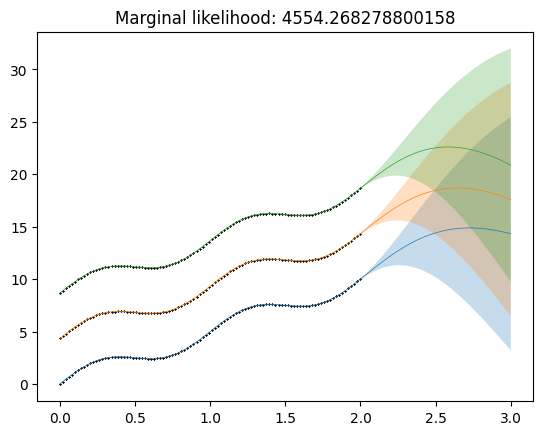

In [8]:
plt.plot(t, Y[:, :3], color='black', marker='x', linestyle='none', ms=1)
plt.plot(t_test, test_mean[:, :3], lw=.5)
plt.fill_between(t_test.squeeze(), test_mean[:, 0] - 2 * test_std[:, 0], test_mean[:, 0] + 2 * test_std[:, 0], alpha=0.25)
plt.fill_between(t_test.squeeze(), test_mean[:, 1] - 2 * test_std[:, 1], test_mean[:, 1] + 2 * test_std[:, 1], alpha=0.25)
plt.fill_between(t_test.squeeze(), test_mean[:, 2] - 2 * test_std[:, 2], test_mean[:, 2] + 2 * test_std[:, 2], alpha=0.25)
plt.title(f"Marginal likelihood: {-gp.filter_energy()}")

In [92]:
# Optimise the hyperparameters
lr_adam = 0.025
epochs = 100

opt_hypers = objax.optimizer.Adam(gp.vars())
energy = objax.GradValues(gp.filter_energy, gp.vars())

def train_op():
    grads, loss_ = energy()  # compute energy and its gradients w.r.t. hypers
    opt_hypers(lr_adam, grads)
    return loss_[0]

train_op = objax.Jit(train_op, gp.vars())

t0 = time.time()
for i in range(1, epochs+1):
    loss = train_op()
    print('epoch %2d: loss: %1.4f' % (i, loss))
t1 = time.time()
print('optimisation time: %2.2f secs' % (t1-t0))

epoch  1: loss: -5016.9443
epoch  2: loss: -5017.1416
epoch  3: loss: -5016.9686
epoch  4: loss: -5017.1564
epoch  5: loss: -5016.9927
epoch  6: loss: -5017.1710
epoch  7: loss: -5017.0167
epoch  8: loss: -5017.1856
epoch  9: loss: -5017.0406
epoch 10: loss: -5017.2001
epoch 11: loss: -5017.0645
epoch 12: loss: -5017.2144
epoch 13: loss: -5017.0882
epoch 14: loss: -5017.2287
epoch 15: loss: -5017.1118
epoch 16: loss: -5017.2429
epoch 17: loss: -5017.1352
epoch 18: loss: -5017.2569
epoch 19: loss: -5017.1586
epoch 20: loss: -5017.2709
epoch 21: loss: -5017.1819
epoch 22: loss: -5017.2848
epoch 23: loss: -5017.2051
epoch 24: loss: -5017.2986
epoch 25: loss: -5017.2282
epoch 26: loss: -5017.3123
epoch 27: loss: -5017.2512
epoch 28: loss: -5017.3259
epoch 29: loss: -5017.2740
epoch 30: loss: -5017.3394
epoch 31: loss: -5017.2968
epoch 32: loss: -5017.3528
epoch 33: loss: -5017.3195
epoch 34: loss: -5017.3661
epoch 35: loss: -5017.3421
epoch 36: loss: -5017.3794
epoch 37: loss: -5017.3646
e

In [93]:
print(lengthscale_spatial, lengthscale_temporal, variance_spatial, variance_temporal)
gp.kernel.spatial_kernel.lengthscale, gp.kernel.temporal_kernel.lengthscale, gp.kernel.spatial_kernel.variance, gp.kernel.temporal_kernel.variance

0.1 1.4 2.0 120


(Array(0.1, dtype=float64, weak_type=True),
 Array(1.49172007, dtype=float64, weak_type=True),
 Array(2., dtype=float64, weak_type=True),
 Array(123.70271722, dtype=float64, weak_type=True))

Text(0.5, 1.0, 'Marginal likelihood: 5018.036060440587')

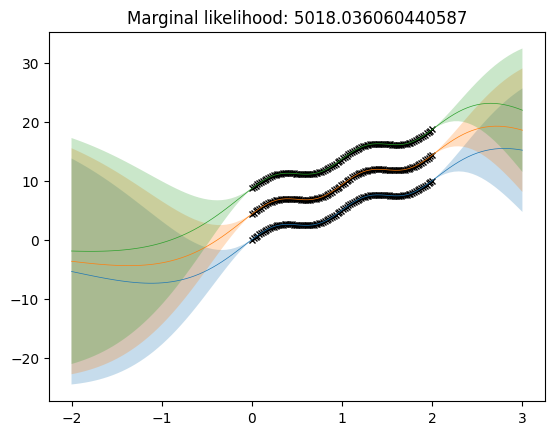

In [95]:
# Extrapolate in time for three spatial locations
t_test = jnp.linspace(-2., 3., 100)[:, None]
test_mean, test_std = gp.predict(t_test)
plt.plot(t, Y[:, :3], color='black', marker='x', linestyle='none', ms=5)
plt.plot(t_test, test_mean[:, :3], lw=.5)
plt.fill_between(t_test.squeeze(), test_mean[:, 0] - 2 * test_std[:, 0], test_mean[:, 0] + 2 * test_std[:, 0], alpha=0.25)
plt.fill_between(t_test.squeeze(), test_mean[:, 1] - 2 * test_std[:, 1], test_mean[:, 1] + 2 * test_std[:, 1], alpha=0.25)
plt.fill_between(t_test.squeeze(), test_mean[:, 2] - 2 * test_std[:, 2], test_mean[:, 2] + 2 * test_std[:, 2], alpha=0.25)
plt.title(f"Marginal likelihood: {-gp.filter_energy()}")

# Spatiotemporal test

In [351]:
np.random.seed(3)

def create_grid(x1, x2, y1, y2, n1=10, n2=10):
    y = np.linspace(y1, y2, n2)
    x = np.linspace(x1, x2, n1)

    grid = []
    for i in x:
        for j in y:
            grid.append([i, j])

    return np.array(grid)

In [352]:
Nt_train = 10
Ns = 5
X = create_grid(0, 1, 0, 1, Nt_train, Ns)
t = np.linspace(0, 1, Nt_train, dtype=float)
R = np.tile(np.linspace(0, 1, Ns, dtype=float)[None, ...], [Nt_train, 1])

N = X.shape[0]
y = np.sin(10*X[:, 0]) + np.sin(10*X[:, 1]) + 0.01*np.random.randn(N)

# Y = y[:, None]
Y = y.reshape(Nt_train, Ns)

# print(R.shape)
# print(Y.shape)
# print(R[0].shape)
# print(X)
# print(R)
# print(R[0])

kernel_ls = [0.1, 0.2]
kernel_var = [2.2, 0.4]
likelihood_noise = 0.1

lik = bayesnewton.likelihoods.Gaussian(variance=likelihood_noise)
kern_time = bayesnewton.kernels.Matern32(variance=kernel_var[0], lengthscale=kernel_ls[0])
kern_space = bayesnewton.kernels.Matern32(variance=kernel_var[1], lengthscale=kernel_ls[1])
kern = bayesnewton.kernels.SpatioTemporalKernel(temporal_kernel=kern_time,
                                                spatial_kernel=kern_space,
                                                z=R[0],
                                                sparse=True,
                                                opt_z=False,
                                                conditional='Full')
t.shape, R.shape, Y.shape

((10,), (10, 5), (10, 5))

In [353]:
model = bayesnewton.models.MarkovVariationalGP(kernel=kern, likelihood=lik, X=t, R=R, Y=Y)

In [354]:
lr_adam = 0.01
lr_newton = 1.
epochs = 10

opt_hypers = objax.optimizer.Adam(model.vars())
energy = objax.GradValues(model.energy, model.vars())

print(model.pseudo_likelihood.mean)

def train_op():
    model.inference(lr=lr_newton)  # perform inference and update variational params
    grads, loss_ = energy()  # compute energy and its gradients w.r.t. hypers
    # print(grads)
    # for g, var_name in zip(grads, model.vars().keys()):  # TODO: this gives wrong label to likelihood variance
        # print(g, ' w.r.t. ', var_name)
    # print(model.kernel.temporal_kernel.variance)
    opt_hypers(lr_adam, grads)
    return loss_[0], model.pseudo_likelihood.mean


train_op = objax.Jit(train_op, model.vars())

t0 = time.time()
for i in range(1, epochs+1):
    loss, mean = train_op()
    print('epoch %2d: loss: %1.4f' % (i, loss))
    print(mean)
t1 = time.time()
print('optimisation time: %2.2f secs' % (t1-t0))

[[[0.]
  [0.]
  [0.]
  [0.]
  [0.]]

 [[0.]
  [0.]
  [0.]
  [0.]
  [0.]]

 [[0.]
  [0.]
  [0.]
  [0.]
  [0.]]

 [[0.]
  [0.]
  [0.]
  [0.]
  [0.]]

 [[0.]
  [0.]
  [0.]
  [0.]
  [0.]]

 [[0.]
  [0.]
  [0.]
  [0.]
  [0.]]

 [[0.]
  [0.]
  [0.]
  [0.]
  [0.]]

 [[0.]
  [0.]
  [0.]
  [0.]
  [0.]]

 [[0.]
  [0.]
  [0.]
  [0.]
  [0.]]

 [[0.]
  [0.]
  [0.]
  [0.]
  [0.]]]
epoch  1: loss: 60.0556
[[[ 0.01788628]
  [ 0.60283724]
  [-0.9579593 ]
  [ 0.91936505]
  [-0.54679499]]

 [[ 0.89264461]
  [ 1.49383693]
  [-0.06900208]
  [ 1.833754  ]
  [ 0.34739891]]

 [[ 0.78208141]
  [ 1.40253842]
  [-0.15489104]
  [ 1.75031576]
  [ 0.25169928]]

 [[-0.19461474]
  [ 0.40245058]
  [-1.16495701]
  [ 0.75725569]
  [-0.74559975]]

 [[-0.97616758]
  [-0.36790147]
  [-1.90837991]
  [-0.02394998]
  [-1.51857608]]

 [[-0.67223145]
  [-0.06037692]
  [-1.62563092]
  [ 0.2652101 ]
  [-1.21142293]]

 [[ 0.38160179]
  [ 0.99238448]
  [-0.59721428]
  [ 1.30588704]
  [-0.17790754]]

 [[ 0.97290706]
  [ 1.58633211]


In [332]:
t_test = np.linspace(0, 1, 100)
model.predict(t_test, np.tile(np.linspace(0, 1, Ns, dtype=float)[None, ...], [len(t_test), 1]))

(Array([[ 1.78148858e-02,  6.04066947e-01, -9.62383348e-01,
          9.25274971e-01, -5.49177219e-01],
        [ 1.14139341e-01,  7.01899087e-01, -8.63812726e-01,
          1.02474130e+00, -4.50723598e-01],
        [ 2.09889916e-01,  7.99156375e-01, -7.65811425e-01,
          1.12363372e+00, -3.52839190e-01],
        [ 3.04129984e-01,  8.94897620e-01, -6.69323439e-01,
          1.22100695e+00, -2.56465976e-01],
        [ 3.95922909e-01,  9.88181618e-01, -5.75292773e-01,
          1.31591573e+00, -1.62545947e-01],
        [ 4.84332039e-01,  1.07806715e+00, -4.84663450e-01,
          1.40741476e+00, -7.20211109e-02],
        [ 5.68420694e-01,  1.16361297e+00, -3.98379517e-01,
          1.49455871e+00,  1.41664988e-02],
        [ 6.47252167e-01,  1.24387780e+00, -3.17385052e-01,
          1.57640224e+00,  9.50748186e-02],
        [ 7.19889713e-01,  1.31792033e+00, -2.42624168e-01,
          1.65199996e+00,  1.69761748e-01],
        [ 7.85396540e-01,  1.38479920e+00, -1.75041026e-01,
    

In [327]:
model.kernel.temporal_kernel.variance, model.kernel.temporal_kernel.lengthscale, model.kernel.spatial_kernel.variance, model.kernel.spatial_kernel.lengthscale, model.likelihood.variance

(Array(99.7965289, dtype=float64, weak_type=True),
 Array(9.28319299, dtype=float64, weak_type=True),
 Array(97.01261454, dtype=float64, weak_type=True),
 Array(8.68600384, dtype=float64, weak_type=True),
 Array(7.33575746e-05, dtype=float64, weak_type=True))

# Toy weather data

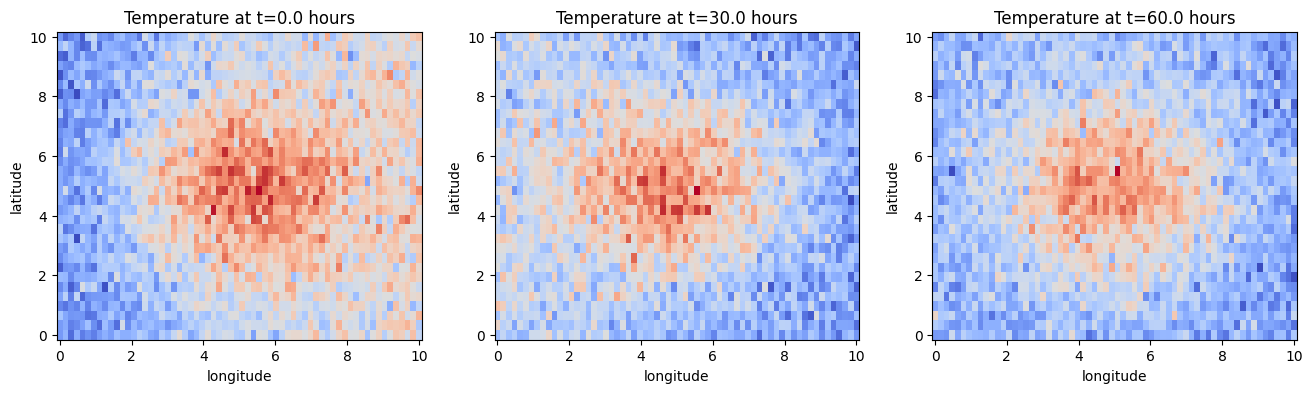

In [ ]:
def toy_weather_function(x, y, t):
    # Spatial smoothing (Gaussian blob with some variation)
    spatial_variation = np.exp(-0.1 * ((x - 5) ** 2 + (y - 5) ** 2))  # Heat island effect
    # Temporal variation (day/night cycle)
    temporal_variation = np.sin(2 * np.pi * t / 24)  # 24-hour cycle
    # Moving weather front (sinusoidal wave moving in x-direction)
    weather_front = np.sin((x-t)/12)   
    # Combine terms
    temperature = 20 + 5 * spatial_variation + 3 * temporal_variation + 5 * weather_front
    return temperature

# Generate a spatiotemporal grid
x_vals = np.linspace(0, 10, 64)
y_vals = np.linspace(0, 10, 32)
t_vals = np.arange(0, 72, 3)

X, Y, T = np.meshgrid(x_vals, y_vals, t_vals, indexing="ij")

noise_level = 1.0
temperature_grid = toy_weather_function(X, Y, T)
temperature_grid_noisy = temperature_grid + noise_level * np.random.randn(*temperature_grid.shape)

# Plot a few time slices
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, t_idx in enumerate([0, 10, 20]):  # Different time snapshots
    ax = axes[i]
    ax.pcolormesh(X[:, :, t_idx], Y[:, :, t_idx], temperature_grid_noisy[:, :, t_idx], cmap="coolwarm")
    ax.set_title(f"Temperature at t={t_vals[t_idx]:.1f} hours")
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")


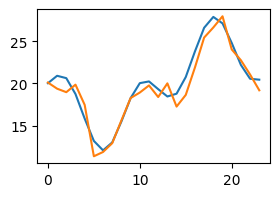

In [ ]:
plt.figure(figsize=(3,2))
plt.plot(temperature_grid[0, 0, :])
plt.plot(temperature_grid_noisy[0, 0, :])

### Generate toy weather data

In [ ]:
x = np.linspace(0, 10, 64)
y = np.linspace(0, 10, 32)
t_train = np.arange(0, 300, 3)

t_test = np.arange(300, 330, 3)

In [ ]:
X_train, Y_train, T_train = np.meshgrid(x, y, t_train)
X_test, Y_test, T_test = np.meshgrid(x, y, t_test)

In [ ]:
np.random.seed(1234)
f_train = toy_weather_function(X_train, Y_train, T_train)
f_train += 1.0 * np.random.randn(*f_train.shape)
f_test_true = toy_weather_function(X_test, Y_test, T_test)

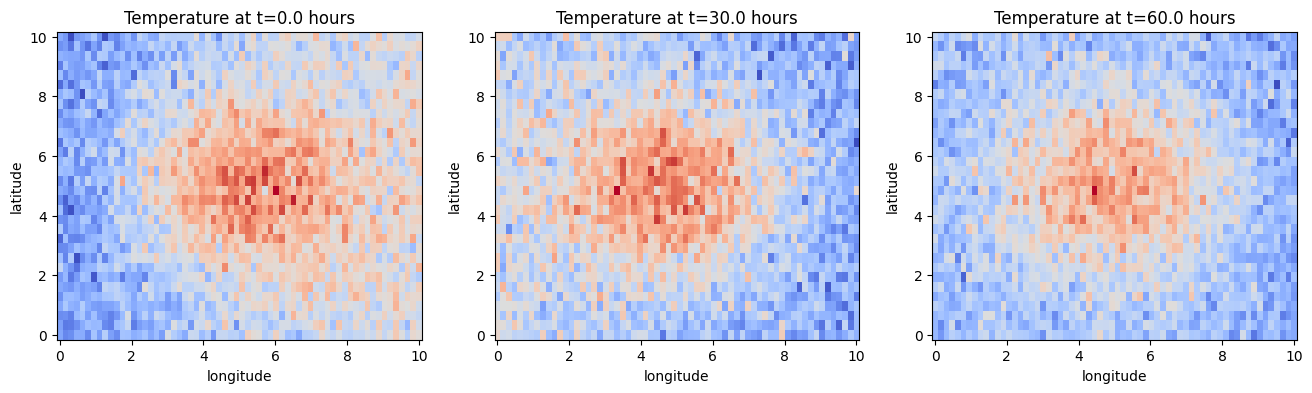

In [ ]:
# Plot a few time slices
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, t_idx in enumerate([0, 10, 20]):  # Different time snapshots
    ax = axes[i]
    ax.pcolormesh(X_train[:, :, t_idx], Y_train[:, :, t_idx], f_train[:, :, t_idx], cmap="coolwarm")
    ax.set_title(f"Temperature at t={t_vals[t_idx]:.1f} hours")
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")